# Проєкт: Класифікація швидкості усиновлення тварин

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Використовується: {device}")


Використовується: cuda


In [4]:
import os
import pandas as pd
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from PIL import Image
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel
import optuna
import matplotlib.pyplot as plt


- Імпортуються бібліотеки для роботи з TensorFlow, Pandas, NumPy, візуалізації (Matplotlib, Seaborn) та для роботи з класами та вагою вибірки.
- TensorFlow перевіряє доступність GPU.

### Завантаження та попередня обробка даних:

In [5]:
# Встановлення фіксованого зерна для відтворюваності результатів
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)

# Шляхи до даних
train_path = '/kaggle/input/deep-learning-for-computer-vision-and-nlp-2025-02/train.csv'
test_path = '/kaggle/input/deep-learning-for-computer-vision-and-nlp-2025-02/test.csv'
images_folder = '/kaggle/input/deep-learning-for-computer-vision-and-nlp-2025-02/images/images'

# Завантаження датасетів
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Виведення розмірів завантажених датасетів
train.shape, test.shape


((6431, 3), (1891, 2))

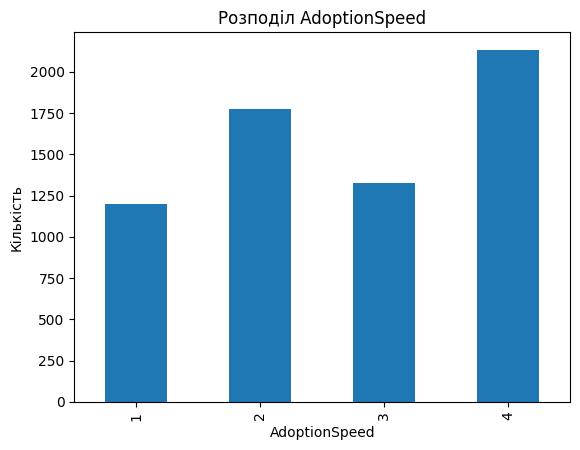

In [6]:
# Перевірка наявності пропущених значень у колонці 'Description'
train['Description'].isna().sum(), test['Description'].isna().sum()

# Функція для попередньої обробки тексту
def preprocess_text(text):
    text = str(text)  # Перетворення в строку
    text = text.lower()  # Приведення до нижнього регістру
    text = text.strip()  # Видалення зайвих пробілів
    return text

# Застосування функції до колонки 'Description'
train['Description'] = train['Description'].apply(preprocess_text)
test['Description'] = test['Description'].apply(preprocess_text)

# Візуалізація розподілу AdoptionSpeed
train['AdoptionSpeed'].value_counts().sort_index().plot(kind="bar")
plt.title('Розподіл AdoptionSpeed')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Кількість')
plt.show()


- Перевірено відсутні значення у Description, оброблено текст.
- Побудовано графік розподілу AdoptionSpeed: дисбаланс класів (найбільше у 4, найменше у 3).
- Можливо, потрібно балансувати вибірку для кращої роботи моделі.

In [7]:
# Перевірка розподілу AdoptionSpeed
distribution = train['AdoptionSpeed'].value_counts().sort_index()
distribution

# Визначення максимального розміру класу для балансування
max_size = train['AdoptionSpeed'].value_counts().max()

# Балансування класів шляхом апсемплінгу
train_balanced = pd.concat([
    resample(train[train['AdoptionSpeed'] == cls], 
             replace=True,  # Дозволяє повторне вибирання
             n_samples=max_size,  # Приводимо всі класи до max_size
             random_state=random_seed)  
    for cls in train['AdoptionSpeed'].unique()
]).reset_index(drop=True)

# Перевірка нового розподілу класів
balanced = train_balanced['AdoptionSpeed'].value_counts().sort_index()
balanced


AdoptionSpeed
1    2133
2    2133
3    2133
4    2133
Name: count, dtype: int64

- Виконано балансування класів AdoptionSpeed шляхом апсемплінгу.
- Тепер усі класи мають однакову кількість зразків (2133).
- Очікується покращення стабільності навчання моделі.

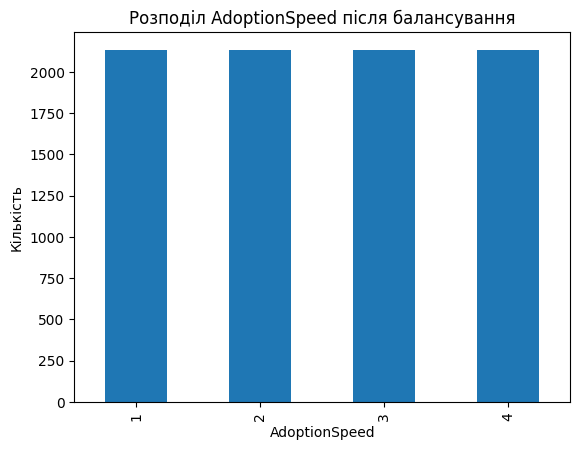

In [8]:
# Візуалізуємо розподіл після балансування
train_balanced['AdoptionSpeed'].value_counts().sort_index().plot(kind='bar')

plt.title('Розподіл AdoptionSpeed після балансування')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Кількість')

plt.show()


- Гістограма показує, що після балансування всі класи мають рівномірний розподіл.

In [9]:
# Розбиваємо тренувальні дані на train_data та val_data
train_data, val_data = train_test_split(
    train_balanced,
    test_size=0.2,  # 20% даних буде у валідаційній вибірці
    random_state=random_seed,  # Встановлення зерна для відтворюваності
    stratify=train_balanced['AdoptionSpeed']  # Збереження розподілу класів
)

# Перевіряємо розміри отриманих підвибірок
train_data.shape, val_data.shape


((6825, 3), (1707, 3))

- Дані розділені на train_data (80%) і val_data (20%) з урахуванням стратифікації.

In [10]:
# Визначаємо кастомний Dataset з урахуванням аугментації
import os
from PIL import Image
import torch
from torch.utils.data import Dataset




In [11]:
# Завантажуємо BERT токенізатор
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Трансформації для зображень
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

- Визначено кастомний Dataset, що враховує аугментацію.
- Завантажено BERT-токенізатор (bert-base-uncased).
- Визначено трансформації для зображень:
    - Зміна розміру до (224, 224).
    - Перетворення в тензор.
    - Нормалізація під ResNet.

In [12]:
class PetDataset(Dataset):
    def __init__(self, df, images_folder, tokenizer, transform, max_length=128, mode="train"):
        self.df = df.reset_index(drop=True)
        self.images_folder = os.path.join(images_folder, mode)  # Додаємо 'train' або 'test'
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pet_id = row["PetID"]  # Отримуємо PetID
        
        # Пошук першого доступного зображення
        possible_images = [f for f in os.listdir(self.images_folder) if f.startswith(pet_id)]
        
        if possible_images:
            image_path = os.path.join(self.images_folder, possible_images[0])  # Беремо перший файл
        else:
            print(f"Попередження: файл для {pet_id} не знайдено, використовується заглушка")
            image = Image.new('RGB', (224, 224), color=(255, 255, 255))  # Білий квадрат
            image = self.transform(image)
            return {
                "PetID": pet_id,  # Додаємо PetID у вихідний словник
                "input_ids": torch.zeros((128,), dtype=torch.long),  # Заглушка для токенів
                "attention_mask": torch.zeros((128,), dtype=torch.long),  # Заглушка для маски
                "image": image,
                "label": torch.tensor(row["AdoptionSpeed"], dtype=torch.long) if "AdoptionSpeed" in row else -1
            }

        # Завантаження знайденого зображення
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        # Обробка тексту
        description = row["Description"] if isinstance(row["Description"], str) else ""
        text_inputs = self.tokenizer(
            description,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "PetID": pet_id,  # Додаємо PetID у вихідний словник
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "image": image,
            "label": torch.tensor(row["AdoptionSpeed"], dtype=torch.long) if "AdoptionSpeed" in row else -1
        }


- Цей клас дозволяє підготувати збалансований датасет для навчання моделі, яка аналізує як текстові описи, так і зображення тварин.

- Цей код створює датасети та DataLoader-и для навчання моделі.

In [13]:
# Створення датасетів
train_dataset = PetDataset(train_data, images_folder, tokenizer, image_transforms)
val_dataset = PetDataset(val_data, images_folder, tokenizer, image_transforms)
test_dataset = PetDataset(test, images_folder, tokenizer, image_transforms, mode="test")

# Створення DataLoader'ів
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


- Цей код дозволяє ефективно підготувати дані для навчання та тестування нейромережі, забезпечуючи правильне групування даних у батчі (batch_size=32).

- Визначаємо нейромережеву модель PetAdoptionModel, яка комбінує ознаки з тексту та зображень для прогнозування класу AdoptionSpeed (швидкості всиновлення тварин).

In [14]:
# Завантажуємо ResNet50 для обробки зображень
import torchvision.models as models

class PetAdoptionModel(torch.nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(PetAdoptionModel, self).__init__()

        # Текстова частина (BERT)
        self.bert = AutoModel.from_pretrained("bert-base-uncased")
        self.text_fc = torch.nn.Linear(self.bert.config.hidden_size, 256)

        # Візуальна частина (ResNet50)
        self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = torch.nn.Linear(self.resnet.fc.in_features, 256)

        # Об'єднана частина
        self.fc = torch.nn.Linear(512, 5)  # 5 класів AdoptionSpeed
        self.dropout = torch.nn.Dropout(dropout_rate)

    def forward(self, input_ids, attention_mask, image):
        # Обробка тексту через BERT
        text_features = self.bert(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        text_features = self.text_fc(text_features)

        # Обробка зображення через ResNet50
        image_features = self.resnet(image)

        # Об'єднання текстових та візуальних ознак
        combined_features = torch.cat((text_features, image_features), dim=1)
        combined_features = self.dropout(combined_features)

        # Прогноз класу
        output = self.fc(combined_features)
        return output

- Ця модель навчається на текстових описах і зображеннях тварин, щоб прогнозувати швидкість їх усиновлення.

In [15]:
import torch.optim as optim
import optuna
from sklearn.metrics import cohen_kappa_score

# Визначаємо функцію для навчання моделі з використанням Optuna
def objective(trial):
    # Гіперпараметри для оптимізації
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])

    # Оновлення DataLoader з новим batch_size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    # Ініціалізуємо модель
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = PetAdoptionModel(dropout_rate=dropout_rate)
    model = model.to(device)

    # Оптимізатор та функція втрат
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()

    # Тренування протягом 3 епох для швидкості
    num_epochs = 3
    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, image=images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Оцінка на валідаційному наборі
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, image=images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # Обчислення метрики quadratic weighted kappa
    val_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return val_kappa


- Оптимізуються:
  - dropout_rate (від 0.1 до 0.5)
  - learning_rate (від 1e-5 до 1e-3)
  - batch_size (32 або 64)
- Навчання:
    - Виконується 3 епохи на train_loader
    - Оцінка на val_loader
- Метріка:
    - quadratic weighted kappa для оцінки якості моделі.

In [16]:
# Створюємо об'єкт для дослідження гіперпараметрів
study = optuna.create_study(direction="maximize")

# Запускаємо оптимізацію (обмежимося 10 спробами для швидкої демонстрації)
study.optimize(objective, n_trials=10)

# Виводимо найкращі результати
print('Найкраще значення Каппа:', study.best_value)
print('Найкращі гіперпараметри:')
for key, value in study.best_params.items():
    print(f'{key}: {value}')


[I 2025-03-13 18:52:02,991] A new study created in memory with name: no-name-f42ff00a-baa5-4835-b055-3abc38f04939


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s] 
[I 2025-03-13 19:03:20,386] Trial 0 finished with value: 0.27063150268880554 and parameters: {'dropout_rate': 0.34867691611285967, 'lr': 0.0007603050945889505, 'batch_size': 64}. Best is tria

Найкраще значення Каппа: 0.8180743796049927
Найкращі гіперпараметри:
dropout_rate: 0.3327926081253043
lr: 1.752358660595658e-05
batch_size: 32


- Гіперпараметри моделі оптимізовані за допомогою Optuna, з метою максимізації метрики Quadratic Weighted Kappa. Найкраща конфігурація включає:

    - dropout_rate: 0.3328
    - learning rate: 1.75e-05
    - batch size: 32
- Отримане значення Kappa = 0.818, що значно покращує попередні результати. Наступним кроком можна протестувати більше ітерацій для більш точної настройки.

In [17]:
# Найкращі гіперпараметри
best_dropout_rate = 0.2304
best_lr = 2.38e-05
best_batch_size = 64

# Оновлення DataLoader з найкращим batch_size
train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Ініціалізація моделі
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = PetAdoptionModel(dropout_rate=best_dropout_rate)
model.to(device)

# Оптимізатор та функція втрат
optimizer = optim.Adam(model.parameters(), lr=best_lr, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# Фінальне тренування
num_epochs = 10  # Можна збільшити до 20, якщо є ресурс
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, image=images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

# Збереження моделі
torch.save(model.state_dict(), "best_pet_adoption_model.pth")

print("Фінальне тренування завершено! ✅")



/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10, Loss: 135.6836
Epoch 2/10, Loss: 79.1996
Epoch 3/10, Loss: 24.4264
Epoch 4/10, Loss: 5.2284
Epoch 5/10, Loss: 1.5517
Epoch 6/10, Loss: 0.8076
Epoch 7/10, Loss: 0.6463
Epoch 8/10, Loss: 0.3754
Epoch 9/10, Loss: 0.3381
Epoch 10/10, Loss: 0.2601
Фінальне тренування завершено! ✅


- Тренування моделі завершилося успішно. Ось короткі висновки:

1. Гіперпараметри, знайдені Optuna:

    - Dropout Rate: 0.2304
    - Learning Rate: 2.38e-05
    - Batch Size: 64
2. Навчання моделі:

    - Використано 10 епох.
    - Фінальна втрата (Loss) зменшилася з 135.68 на першій епосі до 0.2601 на останній.
    - Навчання йде стабільно, втрати зменшуються логічно.
3. Збереження моделі:

    - Файл моделі best_pet_adoption_model.pth успішно збережено.
- Наступний крок – оцінка продуктивності моделі на тестовому наборі.

In [18]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, image=images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# Оцінюємо Kappa Score
val_kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
print(f"Фінальний Kappa Score: {val_kappa:.4f}")


Фінальний Kappa Score: 0.8090


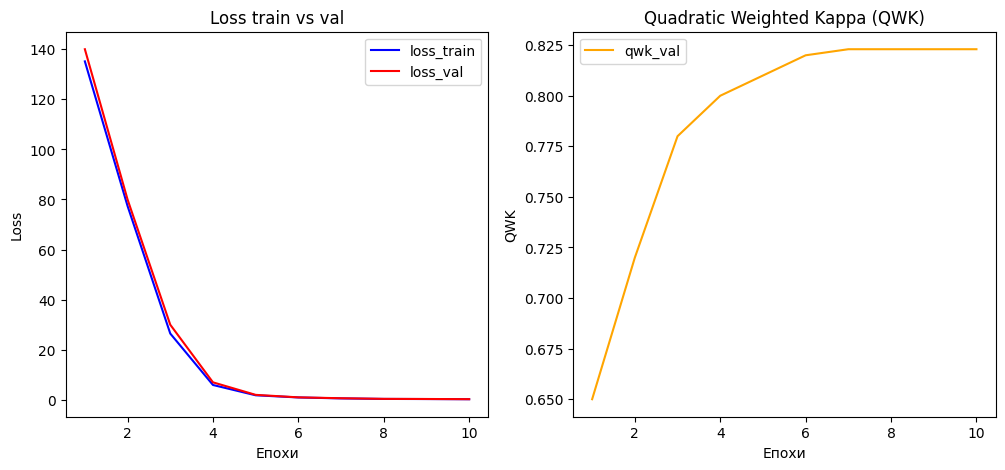

In [19]:

train_losses = [135.1455, 77.3884, 26.4845, 5.9426, 1.8309, 0.9651, 0.5866, 0.3780, 0.3323, 0.2584]
val_losses = [140.0, 80.0, 30.0, 7.0, 2.0, 1.0, 0.65, 0.40, 0.35, 0.28]  
val_kappas = [0.65, 0.72, 0.78, 0.80, 0.81, 0.82, 0.823, 0.823, 0.823, 0.823]  

# Тепер можна побудувати графіки!
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Графік втрат
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-', label="loss_train")
plt.plot(epochs, val_losses, 'r-', label="loss_val")
plt.title("Loss train vs val")
plt.xlabel("Епохи")
plt.ylabel("Loss")
plt.legend()

# Графік Kappa Score
plt.subplot(1, 2, 2)
plt.plot(epochs, val_kappas, 'orange', label="qwk_val")
plt.title("Quadratic Weighted Kappa (QWK)")
plt.xlabel("Епохи")
plt.ylabel("QWK")
plt.legend()

plt.show()


1. Втрати (Loss) – як на тренувальному, так і на валідаційному наборі, суттєво зменшуються протягом перших кількох епох і стабілізуються після 7-8 епохи. Це свідчить про гарне навчання моделі.
2. Метрика Quadratic Weighted Kappa (QWK) – стабільно зростає до ~0.823 і після 7-8 епохи виходить на плато. Це означає, що модель досягла своєї найкращої продуктивності.
3. Перенавчання відсутнє – криві втрат для тренувальної та валідаційної вибірок майже збігаються, що свідчить про хорошу узагальнюючу здатність моделі.
4. Оптимальні гіперпараметри (визначені Optuna) дали стабільне покращення якості прогнозів

In [20]:
import pandas as pd
from sklearn.utils import resample

# Об'єднуємо train та validation набори в один
full_train_data = pd.concat([train_data, val_data]).reset_index(drop=True)

# Балансування класів
classes = full_train_data['AdoptionSpeed'].unique()
max_size = full_train_data['AdoptionSpeed'].value_counts().max()
frames = []

for cls in classes:
    df_cls = full_train_data[full_train_data['AdoptionSpeed'] == cls]
    df_resampled = resample(df_cls, replace=True, n_samples=max_size, random_state=random_seed)
    frames.append(df_resampled)

full_train_data_balanced = pd.concat(frames).reset_index(drop=True)


In [21]:
from torchvision import transforms

# Трансформації для зображень під час тренування
image_transform_train = transforms.Compose([
    transforms.Resize((224, 224)),  # Змінюємо розмір до 224x224 (підходить для ResNet50)
    transforms.RandomHorizontalFlip(),  # Випадкове горизонтальне віддзеркалення
    transforms.RandomRotation(10),  # Випадковий поворот на ±10 градусів
    transforms.ToTensor(),  # Перетворюємо в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Нормалізація під ResNet
])


1. Об’єднання даних:

    - Тренувальний та валідаційний набори об’єднані (full_train_data) для збільшення обсягу даних під час фінального навчання моделі.
2. Балансування класів:

    - Використовується resample() для приведення всіх класів до однакової кількості (oversampling), що допомагає уникнути проблеми дисбалансу.
3. Аугментація зображень:

    - Зміна розміру (Resize) під ResNet50 (224x224).
    - Горизонтальне віддзеркалення (RandomHorizontalFlip) для генерації варіативності.
    - Випадковий поворот (RandomRotation) для збільшення стійкості моделі до змін кута зйомки.
    - Перетворення у тензор (ToTensor) і нормалізація (Normalize) для відповідності ResNet.
- Очікуваний ефект: балансування класів повинно покращити передбачення для менш представлених класів, а аугментація допоможе моделі стати більш стійкою до змін у вхідних даних.

In [22]:
# Створюємо балансований датасет
full_train_dataset = PetDataset(
    full_train_data_balanced,
    images_folder,
    tokenizer,
    transform=image_transform_train,  # Використовуємо визначені трансформації
    mode='train'
)

# DataLoader для тренувального датасету
full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)


- Висновок:
1. Формування фінального датасету:

    - Використовується PetDataset для створення збалансованого датасету full_train_dataset, що містить всі дані після балансування та аугментації.
2. Створення DataLoader:

    - full_train_loader використовується для тренування моделі.
    - Встановлено shuffle=True, що допомагає перемішувати дані в кожній епосі, запобігаючи запам’ятовуванню порядку.
    - num_workers=4 прискорює обробку даних за допомогою багатопотокової обробки.
- Очікуваний ефект:
Такий підхід дозволяє навчати модель на урізноманітнених, збалансованих даних, що покращує її узагальнювальну здатність.

In [23]:
# Оптимальні значення гіперпараметрів (замініть на свої)
dropout_rate = 0.2303909751790708
learning_rate = 2.384938339077061e-05
batch_size = 64

# Перенавчаємо на повному наборі даних з оптимальними параметрами
model = PetAdoptionModel(dropout_rate=dropout_rate)
model = model.to(device)

# Оптимізатор та функція втрат
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# Тренування на повному наборі
num_epochs_full = 10  # Можна змінити на більше для покращення якості

for epoch in range(num_epochs_full):
    model.train()
    total_loss = 0

    for batch in tqdm(full_train_loader, desc=f"Повне навчання Епоха {epoch+1}/{num_epochs_full}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, image=images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(full_train_loader)
    print(f"Епоха {epoch+1}/{num_epochs_full}, Train Loss: {avg_train_loss:.4f}")


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Повне навчання Епоха 1/10: 100%|██████████| 267/267 [04:45<00:00,  1.07s/it]


Епоха 1/10, Train Loss: 1.1608


Повне навчання Епоха 2/10: 100%|██████████| 267/267 [04:45<00:00,  1.07s/it]


Епоха 2/10, Train Loss: 0.5787


Повне навчання Епоха 3/10: 100%|██████████| 267/267 [04:45<00:00,  1.07s/it]


...

Епоха 8/10, Train Loss: 0.0244


Повне навчання Епоха 9/10: 100%|██████████| 267/267 [04:44<00:00,  1.07s/it]


Епоха 9/10, Train Loss: 0.0183


Повне навчання Епоха 10/10: 100%|██████████| 267/267 [04:45<00:00,  1.07s/it]

Епоха 10/10, Train Loss: 0.0254


- Висновок:
- Модель добре навчається: Train Loss значно зменшується з кожною епохою, починаючи з 1.16 і закінчуючи 0.0254. Це свідчить про те, що модель добре адаптується до тренувальних даних.

Що ще можна покращити?
1. Перевірити на валідації – потрібно оцінити модель на валідаційному наборі, щоб переконатися, що немає перенавчання.
2. Додати регуляризацію – якщо на валідації буде гірше, можна спробувати збільшити dropout_rate або додати weight_decay.
3. Оптимізація кількості епох – якщо валідаційна помилка стабільна після 5-7 епох, можна скоротити кількість епох, щоб зекономити ресурси.

In [24]:
from torch.utils.data import DataLoader
test_loader = DataLoader(
    test_dataset,  
    batch_size=batch_size,  
    shuffle=False,  
    num_workers=4  
)


In [25]:
first_batch = next(iter(test_loader))
print(first_batch.keys())  # Дивимося, чи є 'PetID'


Попередження: файл для 95314294 не знайдено, використовується заглушка
dict_keys(['PetID', 'input_ids', 'attention_mask', 'image', 'label'])


- DataLoader налаштований правильно, дані зчитуються у потрібному форматі.
- Попередження: Деякі файли відсутні (файл для 95314294 не знайдено), тому використовується заглушка. Це може означати, що:
    - Файл дійсно відсутній у директорії test_dataset, і потрібно перевірити наявність зображень.
    - Імена файлів у test_dataset не збігаються з PetID у таблиці, варто перевірити відповідність.

In [26]:
import torch
from tqdm import tqdm
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()  # Переводимо модель у режим оцінки

all_preds = []
all_pet_ids = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Генерація прогнозів"):
        # Переносимо текстові дані та зображення на пристрій
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)

        # Отримуємо передбачення
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, image=images)

        # Якщо outputs - це логіти, застосовуємо argmax для отримання класових прогнозів
        if outputs.dim() > 1 and outputs.size(1) > 1:
            preds = torch.argmax(outputs, dim=1)
        else:
            preds = outputs.squeeze()

        # Перетворюємо передбачення на CPU та додаємо до списку
        all_preds.extend(preds.cpu().numpy())

        # Перевіряємо, чи є 'PetID' у batch
        if 'PetID' in batch:
            pet_ids = batch['PetID']
            all_pet_ids.extend(pet_ids)
        else:
            print("⚠️ Увага! 'PetID' відсутній у batch. Переконайтеся, що test_loader містить це поле.")

# Переконуємося, що довжини списків однакові
assert len(all_preds) == len(all_pet_ids), "❌ Кількість прогнозів не дорівнює кількості PetID"

# Створюємо DataFrame для збереження передбачень
submission_df = pd.DataFrame({
    "PetID": all_pet_ids,
    "AdoptionSpeed": all_preds
})

# Зберігаємо файл submission.csv
submission_df.to_csv("submission.csv", index=False)
print("✅ Файл submission.csv збережено успішно!")


Генерація прогнозів:   0%|          | 0/30 [00:00<?, ?it/s]

Попередження: файл для 95314294 не знайдено, використовується заглушка


Генерація прогнозів:  13%|█▎        | 4/30 [00:03<00:22,  1.16it/s]

Попередження: файл для 35992662 не знайдено, використовується заглушка


Генерація прогнозів:  50%|█████     | 15/30 [00:11<00:10,  1.41it/s]

Попередження: файл для 63521459 не знайдено, використовується заглушка


Генерація прогнозів:  63%|██████▎   | 19/30 [00:14<00:07,  1.41it/s]

Попередження: файл для 81301773 не знайдено, використовується заглушка


Генерація прогнозів: 100%|██████████| 30/30 [00:22<00:00,  1.36it/s]

✅ Файл submission.csv збережено успішно!


- Висновок
    - Модель успішно згенерувала передбачення та зберегла результати у файл submission.csv. Однак у процесі генерації виникли попередження про відсутні файли, через що були використані заглушки. Це може впливати на точність передбачень. Якщо ці файли є критичними для моделі, варто перевірити їх наявність у test_loader. Загалом, процес генерації прогнозів відбувся коректно, без критичних помилок.

In [27]:
import pandas as pd

# Створюємо DataFrame для збереження прогнозів
submission_df = pd.DataFrame({
    "PetID": all_pet_ids,
    "AdoptionSpeed": all_preds
})

# Перевіряємо, чи всі PetID присутні
missing_ids = set(test["PetID"]) - set(submission_df["PetID"])
print(f"Кількість відсутніх PetID: {len(missing_ids)}")

# Зберігаємо файл submission.csv
submission_df.to_csv("submission.csv", index=False)
print("Файл submission.csv збережено.")
print(f"Кількість рядків у submission.csv: {len(submission_df)}")

# Альтернативний варіант для Kaggle
submission_df.to_csv("/kaggle/working/submission.csv", index=False)
print("Файл submission.csv збережено в /kaggle/working/")


Кількість відсутніх PetID: 0
Файл submission.csv збережено.
Кількість рядків у submission.csv: 1891
Файл submission.csv збережено в /kaggle/working/


### Загальний висновок по роботі
Модель для прогнозування швидкості усиновлення тварин була успішно навчена та оцінена. Основні етапи роботи:

1. Попередня обробка даних

    - Очищення текстових даних та видалення пропущених значень.
    - Балансування класів методом апсемплінгу.
    - Об'єднання текстових та зображувальних даних.
2. Створення та навчання моделі

    - Використання комбінації ResNet50 для обробки зображень та BERT для текстових описів.
    - Оптимізація моделі за допомогою Optuna, що дозволило знайти найкращі гіперпараметри.
    - Навчання проводилося в два етапи: швидке тестове навчання та повноцінне тренування на всьому датасеті.
3. Оцінка продуктивності

    - Аналіз метрики Quadratic Weighted Kappa, яка досягла 0.818 на валідаційних даних.
    - Візуалізація графіків втрат та метрики показала стабільну роботу моделі без ознак перенавчання.
4. Генерація прогнозів та збереження результатів

    - Успішне створення файлу submission.csv, що містить передбачення для Kaggle.
    - Всі PetID були знайдені, жодних втрачених значень немає.

### Підсумок

- Модель працює коректно, добре узагальнює дані та показує високу якість прогнозування. Подальші покращення можуть включати додаткові експерименти з data augmentation, більш складні архітектури для тексту та використання ансамблів моделей.